(pd)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# {index}`Pandas <single: Pandas>`

```{index} single: Python; Pandas
```

Anaconda-യിൽ ഉള്ളതിന് പുറമെ, ഈ lecture-ന് താഴെപ്പറയുന്ന libraries ആവശ്യമാണ്:

In [1]:
!pip install --upgrade wbgapi
!pip install --upgrade yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/13.5 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━ 10.5/13.5 MB 59.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 58.7 MB/s  0:00:00


   ━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━ 2/5 [peewee]
   ━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━ 3/5 [curl_cffi]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━ 4/5 [yfinance]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [yfinance]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/13.5 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━ 10.5/13.5 MB 59.3 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 58.7 MB/s  0:00:00


   ━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━ 2/5 [peewee]

   ━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━ 3/5 [curl_cffi]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━ 4/5 [yfinance]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [yfinance]


## Overview

[Pandas](https://pandas.pydata.org/) എന്നത് Python-നുള്ള വേഗതയേറിയതും കാര്യക്ഷമവുമായ data analysis tools-ന്റെ ഒരു package ആണ്.

data science, machine learning തുടങ്ങിയ മേഖലകളുടെ വളർച്ചയ്‌ക്കൊപ്പം ഇതിന്റെ popularity കഴിഞ്ഞ വർഷങ്ങളിൽ കുതിച്ചുയർന്നിട്ടുണ്ട്.

Stack Overflow Trends-ന്റെ സഹായത്തോടെ Matlab, STATA എന്നിവയുമായി താരതമ്യപ്പെടുത്തി കാലക്രമേണ ഉള്ള ഒരു popularity comparison ഇതാ

```{figure} /_static/lecture_specific/pandas/pandas_vs_rest.png
:scale: 100
```

[NumPy](https://numpy.org/) അടിസ്ഥാന array data type-ഉം core array operations-ഉം നൽകുന്നത് പോലെ, pandas

1. data-യുമായി പ്രവർത്തിക്കാൻ ആവശ്യമായ fundamental structures define ചെയ്യുന്നു, ഒപ്പം
1. താഴെപ്പറയുന്നത് പോലുള്ള operations എളുപ്പമാക്കുന്ന methods അവയ്ക്ക് നൽകുന്നു
    * data reading ചെയ്യുക
    * indices adjust ചെയ്യുക
    * dates, time series എന്നിവയുമായി പ്രവർത്തിക്കുക
    * sorting, grouping, re-ordering, general data munging [^mung]
    * missing values കൈകാര്യം ചെയ്യുക, തുടങ്ങിയവ

കൂടുതൽ sophisticated ആയ statistical functionality [statsmodels](https://www.statsmodels.org/), [scikit-learn](https://scikit-learn.org/) പോലുള്ള pandas-ന്റെ മുകളിൽ built ചെയ്ത മറ്റ് packages-നായി വിട്ടിരിക്കുന്നു.

ഈ lecture pandas-നെ കുറിച്ചുള്ള ഒരു basic introduction നൽകും.

ലക്ചർ മുഴുവൻ, താഴെപ്പറയുന്ന imports നടന്നിട്ടുണ്ട് എന്ന് നമ്മൾ assume ചെയ്യും

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

pandas define ചെയ്യുന്ന രണ്ട് പ്രധാന data types `Series`-ഉം `DataFrame`-ഉം ആണ്.

`Series`-നെ data-യുടെ ഒരു "column" ആയി ചിന്തിക്കാം, ഒരു single variable-ന്റെ observations-ന്റെ ഒരു collection പോലെ.

related columns of data സൂക്ഷിക്കാനുള്ള ഒരു two-dimensional object ആണ് `DataFrame`.

## Series

```{index} single: Pandas; Series
```

നമുക്ക് Series-ൽ നിന്ന് തുടങ്ങാം.

നാല് random observations-ന്റെ ഒരു series create ചെയ്തുകൊണ്ട് നമ്മൾ ആരംഭിക്കുന്നു

In [3]:
s = pd.Series(np.random.randn(4), name='daily returns')
s

0   -1.652421
1    0.014571
2   -0.721377
3    1.202616
Name: daily returns, dtype: float64

ഇവിടെ `0, 1, 2, 3` എന്ന indices നാല് listed companies-നെ index ചെയ്യുന്നതായും, values അവയുടെ shares-ന്റെ daily returns ആയും നിങ്ങൾക്ക് സങ്കൽപ്പിക്കാം.

Pandas `Series` NumPy arrays-ന്റെ മുകളിൽ built ചെയ്തതാണ്, അതിനാൽ സമാനമായ പല operations-ഉം support ചെയ്യുന്നു

In [4]:
s * 100

0   -165.242090
1      1.457078
2    -72.137689
3    120.261582
Name: daily returns, dtype: float64

In [5]:
np.abs(s)

0    1.652421
1    0.014571
2    0.721377
3    1.202616
Name: daily returns, dtype: float64

എന്നാൽ `Series` NumPy arrays-നേക്കാൾ കൂടുതൽ നൽകുന്നു.

അധിക (statistically oriented) methods ഉള്ളതിന് പുറമെ

In [6]:
s.describe()

count    4.000000
mean    -0.289153
std      1.205949
min     -1.652421
25%     -0.954138
50%     -0.353403
75%      0.311582
max      1.202616
Name: daily returns, dtype: float64

അവയുടെ indices കൂടുതൽ flexible ആണ്

In [7]:
s.index = ['AMZN', 'AAPL', 'MSFT', 'GOOG']
s

AMZN   -1.652421
AAPL    0.014571
MSFT   -0.721377
GOOG    1.202616
Name: daily returns, dtype: float64

ഈ രീതിയിൽ കാണുമ്പോൾ, `Series` വേഗതയേറിയതും കാര്യക്ഷമവുമായ Python dictionaries-നെ പോലെയാണ് (dictionary-യിലെ items എല്ലാം ഒരേ type-ന്റെ ആയിരിക്കണം എന്ന restriction ഉണ്ട്---ഈ case-ൽ, floats).

വാസ്തവത്തിൽ, Python dictionaries-ൽ ഉപയോഗിക്കുന്ന syntax തന്നെ നിങ്ങൾക്ക് ഉപയോഗിക്കാം

In [8]:
s['AMZN']

np.float64(-1.652420902398222)

In [9]:
s['AMZN'] = 0
s

AMZN    0.000000
AAPL    0.014571
MSFT   -0.721377
GOOG    1.202616
Name: daily returns, dtype: float64

In [10]:
'AAPL' in s

True

## DataFrames

```{index} single: Pandas; DataFrames
```

`Series` data-യുടെ ഒറ്റ column ആണെങ്കിൽ, `DataFrame` ഓരോ variable-നും ഒരു column വീതം ഉള്ള പല columns ആണ്.

അടിസ്ഥാനപരമായി, pandas-ലെ `DataFrame` ഒരു (highly optimized) Excel spreadsheet-ന് സമാനമാണ്.

അതിനാൽ, rows-ഉം columns-ഉം ആയി സ്വാഭാവികമായി organize ചെയ്യപ്പെട്ട data represent ചെയ്യാനും analyze ചെയ്യാനും ഉള്ള ശക്തമായ ഒരു tool ആണിത്, individual rows-നും individual columns-നും വേണ്ടി descriptive indexes ഉള്ളതോടെ.

[Penn World Tables](https://www.rug.nl/ggdc/productivity/pwt/pwt-releases/pwt-7.0)-ൽ നിന്ന് എടുത്ത `pandas/data/test_pwt.csv` എന്ന CSV file-ൽ നിന്ന് data read ചെയ്യുന്ന ഒരു example നോക്കാം.

Dataset-ൽ താഴെപ്പറയുന്ന indicators അടങ്ങിയിരിക്കുന്നു

| Variable Name | Description |
| :-: | :-: |
| POP | Population (in thousands) |
| XRAT | Exchange Rate to US Dollar |                     
| tcgdp | Total PPP Converted GDP (in million international dollar) |
| cc | Consumption Share of PPP Converted GDP Per Capita (%) |
| cg | Government Consumption Share of PPP Converted GDP Per Capita (%) |


`pandas` function ആയ `read_csv` ഉപയോഗിച്ച് നമ്മൾ ഇത് ഒരു URL-ൽ നിന്ന് read ചെയ്യും.

In [11]:
df = pd.read_csv('https://raw.githubusercontent.com/QuantEcon/lecture-python-programming/main/lectures/_static/lecture_specific/pandas/data/test_pwt.csv')
type(df)

pandas.DataFrame

`test_pwt.csv`-ന്റെ content ഇതാ

In [12]:
df

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
0,Argentina,ARG,2000,37335.653,0.999500,2.950722e+05,75.716805,5.578804
1,Australia,AUS,2000,19053.186,1.724830,5.418047e+05,67.759026,6.720098
2,India,IND,2000,1006300.297,44.941600,1.728144e+06,64.575551,14.072206
3,Israel,ISR,2000,6114.570,4.077330,1.292539e+05,64.436451,10.266688
4,Malawi,MWI,2000,11801.505,59.543808,5.026222e+03,74.707624,11.658954
5,South Africa,ZAF,2000,45064.098,6.939830,2.272424e+05,72.718710,5.726546
6,United States,USA,2000,282171.957,1.000000,9.898700e+06,72.347054,6.032454
7,Uruguay,URY,2000,3219.793,12.099592,2.525596e+04,78.978740,5.108068


### Select Data by Position

Practice-ൽ, നമ്മൾ എപ്പോഴും ചെയ്യുന്ന ഒരു കാര്യം നമ്മുടെ interest ഉള്ള data-യുടെ ഒരു subset find ചെയ്യുകയും select ചെയ്യുകയും അതുമായി പ്രവർത്തിക്കുകയും ചെയ്യുക എന്നതാണ്.

standard Python array slicing notation ഉപയോഗിച്ച് നമുക്ക് particular rows select ചെയ്യാം

In [13]:
df[2:5]

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
2,India,IND,2000,1006300.297,44.941600,1.728144e+06,64.575551,14.072206
3,Israel,ISR,2000,6114.570,4.077330,1.292539e+05,64.436451,10.266688
4,Malawi,MWI,2000,11801.505,59.543808,5.026222e+03,74.707624,11.658954


Columns select ചെയ്യാൻ, ആവശ്യമുള്ള columns-ന്റെ names strings ആയി represent ചെയ്യുന്ന ഒരു list നമുക്ക് pass ചെയ്യാം

In [14]:
df[['country', 'tcgdp']]

,country,tcgdp
0,Argentina,2.950722e+05
1,Australia,5.418047e+05
2,India,1.728144e+06
3,Israel,1.292539e+05
4,Malawi,5.026222e+03
5,South Africa,2.272424e+05
6,United States,9.898700e+06
7,Uruguay,2.525596e+04


integers ഉപയോഗിച്ച് rows-ഉം columns-ഉം select ചെയ്യാൻ, `.iloc[rows, columns]` എന്ന format-ൽ `iloc` attribute ഉപയോഗിക്കണം.

In [15]:
df.iloc[2:5, 0:4]

,country,country isocode,year,POP
2,India,IND,2000,1006300.297
3,Israel,ISR,2000,6114.570
4,Malawi,MWI,2000,11801.505


integers-ഉം labels-ഉം കൂടിക്കലർത്തി rows-ഉം columns-ഉം select ചെയ്യാൻ, `loc` attribute സമാനമായ രീതിയിൽ ഉപയോഗിക്കാം

In [16]:
df.loc[df.index[2:5], ['country', 'tcgdp']]

,country,tcgdp
2,India,1.728144e+06
3,Israel,1.292539e+05
4,Malawi,5.026222e+03


### Select Data by Conditions

integers-ഉം names-ഉം ഉപയോഗിച്ച് rows-ഉം columns-ഉം index ചെയ്യുന്നതിന് പകരം, ചില (potentially complicated) conditions satisfy ചെയ്യുന്ന നമ്മുടെ interest ഉള്ള ഒരു sub-dataframe-ഉം നമുക്ക് ലഭിക്കും.

ഇത് ചെയ്യാനുള്ള വിവിധ വഴികൾ ഈ section demonstrate ചെയ്യുന്നു.

ഏറ്റവും straightforward ആയ വഴി `[]` operator ഉപയോഗിച്ചാണ്.

In [17]:
df[df.POP >= 20000]

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
0,Argentina,ARG,2000,37335.653,0.99950,2.950722e+05,75.716805,5.578804
2,India,IND,2000,1006300.297,44.94160,1.728144e+06,64.575551,14.072206
5,South Africa,ZAF,2000,45064.098,6.93983,2.272424e+05,72.718710,5.726546
6,United States,USA,2000,282171.957,1.00000,9.898700e+06,72.347054,6.032454


ഇവിടെ എന്താണ് സംഭവിക്കുന്നത് എന്ന് മനസ്സിലാക്കാൻ, `df.POP >= 20000` boolean values-ന്റെ ഒരു series return ചെയ്യുന്നു എന്ന് ശ്രദ്ധിക്കുക.

In [18]:
df.POP >= 20000

0     True
1    False
2     True
3    False
4    False
5     True
6     True
7    False
Name: POP, dtype: bool

ഈ case-ൽ, `df[___]` boolean values-ന്റെ ഒരു series എടുത്ത് `True` values ഉള്ള rows മാത്രം return ചെയ്യുന്നു.

ഒരു ഉദാഹരണം കൂടി എടുക്കാം,

In [19]:
df[(df.country.isin(['Argentina', 'India', 'South Africa'])) & (df.POP > 40000)]

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
2,India,IND,2000,1006300.297,44.94160,1.728144e+06,64.575551,14.072206
5,South Africa,ZAF,2000,45064.098,6.93983,2.272424e+05,72.718710,5.726546


എന്നിരുന്നാലും, ഇതേ കാര്യം ചെയ്യാൻ മറ്റൊരു വഴിയുണ്ട്, അത് വലിയ dataframes-ന് കുറച്ചുകൂടി വേഗതയേറിയതും, കൂടുതൽ natural ആയ syntax-ഉള്ളതും ആണ്.

In [20]:
# the above is equivalent to 
df.query("POP >= 20000")

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
0,Argentina,ARG,2000,37335.653,0.99950,2.950722e+05,75.716805,5.578804
2,India,IND,2000,1006300.297,44.94160,1.728144e+06,64.575551,14.072206
5,South Africa,ZAF,2000,45064.098,6.93983,2.272424e+05,72.718710,5.726546
6,United States,USA,2000,282171.957,1.00000,9.898700e+06,72.347054,6.032454


In [21]:
df.query("country in ['Argentina', 'India', 'South Africa'] and POP > 40000")

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
2,India,IND,2000,1006300.297,44.94160,1.728144e+06,64.575551,14.072206
5,South Africa,ZAF,2000,45064.098,6.93983,2.272424e+05,72.718710,5.726546


വ്യത്യസ്ത columns-ന് ഇടയിൽ arithmetic operations-ഉം നമുക്ക് allow ചെയ്യാം.

In [22]:
df[(df.cc + df.cg >= 80) & (df.POP <= 20000)]

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
4,Malawi,MWI,2000,11801.505,59.543808,5026.221784,74.707624,11.658954
7,Uruguay,URY,2000,3219.793,12.099592,25255.961693,78.978740,5.108068


In [23]:
# the above is equivalent to 
df.query("cc + cg >= 80 & POP <= 20000")

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
4,Malawi,MWI,2000,11801.505,59.543808,5026.221784,74.707624,11.658954
7,Uruguay,URY,2000,3219.793,12.099592,25255.961693,78.978740,5.108068


ഉദാഹരണത്തിന്, ഏറ്റവും വലിയ household consumption - gdp share `cc` ഉള്ള country select ചെയ്യാൻ conditioning ഉപയോഗിക്കാം.

In [24]:
df.loc[df.cc == max(df.cc)]

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
7,Uruguay,URY,2000,3219.793,12.099592,25255.961693,78.97874,5.108068


selected sub-dataframe-ന്റെ ചില columns മാത്രം നമുക്ക് നോക്കണമെങ്കിൽ, മുകളിലുള്ള conditions `.loc[__ , __]` command-ഉമായി ഉപയോഗിക്കാം.

ആദ്യത്തെ argument condition എടുക്കുന്നു, രണ്ടാമത്തെ argument നമുക്ക് return വേണ്ട columns-ന്റെ ഒരു list എടുക്കുന്നു.

In [25]:
df.loc[(df.cc + df.cg >= 80) & (df.POP <= 20000), ['country', 'year', 'POP']]

,country,year,POP
4,Malawi,2000,11801.505
7,Uruguay,2000,3219.793


**Application: Subsetting Dataframe**

Real-world datasets [enormous](https://developers.google.com/machine-learning/crash-course/overfitting) ആയിരിക്കാം.

computational efficiency വർദ്ധിപ്പിക്കാനും redundancy കുറയ്ക്കാനും data-യുടെ ഒരു subset ഉപയോഗിച്ച് പ്രവർത്തിക്കുന്നത് ചിലപ്പോൾ desirable ആണ്.

Population (`POP`)-ഉം total GDP (`tcgdp`)-ഉം മാത്രമേ നമുക്ക് interest ഉള്ളൂ എന്ന് സങ്കൽപ്പിക്കാം.

`df` എന്ന data frame ഈ variables മാത്രം ആയി strip ചെയ്യാനുള്ള ഒരു വഴി, മുകളിൽ വിവരിച്ച selection method ഉപയോഗിച്ച് dataframe overwrite ചെയ്യുക എന്നതാണ്

In [26]:
df_subset = df[['country', 'POP', 'tcgdp']]
df_subset

,country,POP,tcgdp
0,Argentina,37335.653,2.950722e+05
1,Australia,19053.186,5.418047e+05
2,India,1006300.297,1.728144e+06
3,Israel,6114.570,1.292539e+05
4,Malawi,11801.505,5.026222e+03
5,South Africa,45064.098,2.272424e+05
6,United States,282171.957,9.898700e+06
7,Uruguay,3219.793,2.525596e+04


തുടർന്ന്, further analysis-ന് വേണ്ടി ഈ ചെറിയ dataset നമുക്ക് save ചെയ്യാം.

```{code-block} python3
:class: no-execute

df_subset.to_csv('pwt_subset.csv', index=False)
```

### Apply Method

വ്യാപകമായി ഉപയോഗിക്കുന്ന മറ്റൊരു Pandas method ആണ് `df.apply()`.

ഇത് ഓരോ row/column-നും ഒരു function apply ചെയ്യുകയും ഒരു series return ചെയ്യുകയും ചെയ്യുന്നു.

ഈ function `max` function പോലുള്ള ചില built-in functions, ഒരു `lambda` function, അല്ലെങ്കിൽ ഒരു user-defined function ആകാം.

`max` function ഉപയോഗിച്ചുള്ള ഒരു ഉദാഹരണം ഇതാ

In [27]:
df[['year', 'POP', 'XRAT', 'tcgdp', 'cc', 'cg']].apply(max)

year     2.000000e+03
POP      1.006300e+06
XRAT     5.954381e+01
tcgdp    9.898700e+06
cc       7.897874e+01
cg       1.407221e+01
dtype: float64

ഈ code-ന്റെ line എല്ലാ selected columns-ലും `max` function apply ചെയ്യുന്നു.

`df.apply()` method-ഉമായി `lambda` function പലപ്പോഴും ഉപയോഗിക്കാറുണ്ട്

dataframe-ലെ ഓരോ row-ക്കും തന്നെ return ചെയ്യുക എന്നത് ഒരു trivial ഉദാഹരണമാണ്

In [28]:
df.apply(lambda row: row, axis=1)

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
0,Argentina,ARG,2000,37335.653,0.999500,2.950722e+05,75.716805,5.578804
1,Australia,AUS,2000,19053.186,1.724830,5.418047e+05,67.759026,6.720098
2,India,IND,2000,1006300.297,44.941600,1.728144e+06,64.575551,14.072206
3,Israel,ISR,2000,6114.570,4.077330,1.292539e+05,64.436451,10.266688
4,Malawi,MWI,2000,11801.505,59.543808,5.026222e+03,74.707624,11.658954
5,South Africa,ZAF,2000,45064.098,6.939830,2.272424e+05,72.718710,5.726546
6,United States,USA,2000,282171.957,1.000000,9.898700e+06,72.347054,6.032454
7,Uruguay,URY,2000,3219.793,12.099592,2.525596e+04,78.978740,5.108068


```{note}
`.apply()` method-ന്
- axis = 0 -- ഓരോ column-നും (variables) function apply ചെയ്യുന്നു
- axis = 1 -- ഓരോ row-ക്കും (observations) function apply ചെയ്യുന്നു
- axis = 0 ആണ് default parameter
```

കൂടുതൽ advanced ആയ selection ചെയ്യാൻ `.loc[]`-ഉമായി ചേർത്ത് നമുക്ക് ഇത് ഉപയോഗിക്കാം.

In [29]:
complexCondition = df.apply(
    lambda row: row.POP > 40000 if row.country in ['Argentina', 'India', 'South Africa'] else row.POP < 20000, 
    axis=1), ['country', 'year', 'POP', 'XRAT', 'tcgdp']

if-else statement-ൽ specify ചെയ്ത condition satisfy ചെയ്യുന്ന rows-ന്റെ boolean values-ന്റെ ഒരു series ഇവിടെ `df.apply()` return ചെയ്യുന്നു.

കൂടാതെ, interest ഉള്ള variables-ന്റെ ഒരു subset-ഉം ഇത് define ചെയ്യുന്നു.

In [30]:
complexCondition

(0    False
 1     True
 2     True
 3     True
 4     True
 5     True
 6    False
 7     True
 dtype: bool,
 ['country', 'year', 'POP', 'XRAT', 'tcgdp'])

ഈ condition dataframe-ൽ apply ചെയ്യുമ്പോൾ, result ഇതായിരിക്കും

In [31]:
df.loc[complexCondition]

,country,year,POP,XRAT,tcgdp
1,Australia,2000,19053.186,1.724830,5.418047e+05
2,India,2000,1006300.297,44.941600,1.728144e+06
3,Israel,2000,6114.570,4.077330,1.292539e+05
4,Malawi,2000,11801.505,59.543808,5.026222e+03
5,South Africa,2000,45064.098,6.939830,2.272424e+05
7,Uruguay,2000,3219.793,12.099592,2.525596e+04


### Make Changes in DataFrames

future analysis-ന് വേണ്ടി ഒരു clean dataset generate ചെയ്യാൻ dataframes-ൽ changes ഉണ്ടാക്കാനുള്ള ability പ്രധാനമാണ്.


**1.** നമ്മൾ select ചെയ്ത rows "keep" ചെയ്യാനും ബാക്കിയുള്ള rows `NaN` ആയി replace ചെയ്യാനും `df.where()` സൗകര്യപ്രദമായി ഉപയോഗിക്കാം

In [32]:
df.where(df.POP >= 20000)

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
0,Argentina,ARG,2000.0,37335.653,0.99950,2.950722e+05,75.716805,5.578804
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,India,IND,2000.0,1006300.297,44.94160,1.728144e+06,64.575551,14.072206
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,South Africa,ZAF,2000.0,45064.098,6.93983,2.272424e+05,72.718710,5.726546
6,United States,USA,2000.0,282171.957,1.00000,9.898700e+06,72.347054,6.032454
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**2.** modify ചെയ്യേണ്ട column specify ചെയ്യാൻ `.loc[]` ലളിതമായി ഉപയോഗിച്ച് values assign ചെയ്യാം

In [33]:
df.loc[df.cg == max(df.cg), 'cg'] = np.nan
df

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
0,Argentina,ARG,2000,37335.653,0.999500,2.950722e+05,75.716805,5.578804
1,Australia,AUS,2000,19053.186,1.724830,5.418047e+05,67.759026,6.720098
2,India,IND,2000,1006300.297,44.941600,1.728144e+06,64.575551,NaN
3,Israel,ISR,2000,6114.570,4.077330,1.292539e+05,64.436451,10.266688
4,Malawi,MWI,2000,11801.505,59.543808,5.026222e+03,74.707624,11.658954
5,South Africa,ZAF,2000,45064.098,6.939830,2.272424e+05,72.718710,5.726546
6,United States,USA,2000,282171.957,1.000000,9.898700e+06,72.347054,6.032454
7,Uruguay,URY,2000,3219.793,12.099592,2.525596e+04,78.978740,5.108068


**3.** *rows/columns as a whole* modify ചെയ്യാൻ `.apply()` method ഉപയോഗിക്കാം

In [34]:
def update_row(row):
    # modify POP
    row.POP = np.nan if row.POP<= 10000 else row.POP

    # modify XRAT
    row.XRAT = row.XRAT / 10
    return row

df.apply(update_row, axis=1)

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
0,Argentina,ARG,2000,37335.653,0.099950,2.950722e+05,75.716805,5.578804
1,Australia,AUS,2000,19053.186,0.172483,5.418047e+05,67.759026,6.720098
2,India,IND,2000,1006300.297,4.494160,1.728144e+06,64.575551,NaN
3,Israel,ISR,2000,NaN,0.407733,1.292539e+05,64.436451,10.266688
4,Malawi,MWI,2000,11801.505,5.954381,5.026222e+03,74.707624,11.658954
5,South Africa,ZAF,2000,45064.098,0.693983,2.272424e+05,72.718710,5.726546
6,United States,USA,2000,282171.957,0.100000,9.898700e+06,72.347054,6.032454
7,Uruguay,URY,2000,NaN,1.209959,2.525596e+04,78.978740,5.108068


**4.** dataframe-ലെ എല്ലാ *individual entries*-ഉം ഒരുമിച്ച് modify ചെയ്യാൻ `.map()` method ഉപയോഗിക്കാം.

In [35]:
# Round all decimal numbers to 2 decimal places
df.map(lambda x : round(x,2) if type(x)!=str else x)

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
0,Argentina,ARG,2000,37335.65,1.00,295072.22,75.72,5.58
1,Australia,AUS,2000,19053.19,1.72,541804.65,67.76,6.72
2,India,IND,2000,1006300.30,44.94,1728144.37,64.58,NaN
3,Israel,ISR,2000,6114.57,4.08,129253.89,64.44,10.27
4,Malawi,MWI,2000,11801.50,59.54,5026.22,74.71,11.66
5,South Africa,ZAF,2000,45064.10,6.94,227242.37,72.72,5.73
6,United States,USA,2000,282171.96,1.00,9898700.00,72.35,6.03
7,Uruguay,URY,2000,3219.79,12.10,25255.96,78.98,5.11


**Application: Missing Value Imputation**

Missing values replace ചെയ്യുന്നത് data munging-ലെ ഒരു പ്രധാന step ആണ്.

നമുക്ക് randomly ചില NaN values insert ചെയ്യാം

In [36]:
for idx in list(zip([0, 3, 5, 6], [3, 4, 6, 2])):
    df.iloc[idx] = np.nan

df

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
0,Argentina,ARG,2000.0,NaN,0.999500,2.950722e+05,75.716805,5.578804
1,Australia,AUS,2000.0,19053.186,1.724830,5.418047e+05,67.759026,6.720098
2,India,IND,2000.0,1006300.297,44.941600,1.728144e+06,64.575551,NaN
3,Israel,ISR,2000.0,6114.570,NaN,1.292539e+05,64.436451,10.266688
4,Malawi,MWI,2000.0,11801.505,59.543808,5.026222e+03,74.707624,11.658954
5,South Africa,ZAF,2000.0,45064.098,6.939830,2.272424e+05,NaN,5.726546
6,United States,USA,NaN,282171.957,1.000000,9.898700e+06,72.347054,6.032454
7,Uruguay,URY,2000.0,3219.793,12.099592,2.525596e+04,78.978740,5.108068


ഇവിടെ `zip()` function രണ്ട് lists-ൽ നിന്ന് values-ന്റെ pairs create ചെയ്യുന്നു (അതായത് [0,3], [3,4] ...)

എല്ലാ missing values-ഉം 0 ആയി replace ചെയ്യാൻ വീണ്ടും `.map()` method നമുക്ക് ഉപയോഗിക്കാം

In [37]:
# replace all NaN values by 0
def replace_nan(x):
    if type(x)!=str:
        return  0 if np.isnan(x) else x
    else:
        return x

df.map(replace_nan)

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
0,Argentina,ARG,2000.0,0.000,0.999500,2.950722e+05,75.716805,5.578804
1,Australia,AUS,2000.0,19053.186,1.724830,5.418047e+05,67.759026,6.720098
2,India,IND,2000.0,1006300.297,44.941600,1.728144e+06,64.575551,0.000000
3,Israel,ISR,2000.0,6114.570,0.000000,1.292539e+05,64.436451,10.266688
4,Malawi,MWI,2000.0,11801.505,59.543808,5.026222e+03,74.707624,11.658954
5,South Africa,ZAF,2000.0,45064.098,6.939830,2.272424e+05,0.000000,5.726546
6,United States,USA,0.0,282171.957,1.000000,9.898700e+06,72.347054,6.032454
7,Uruguay,URY,2000.0,3219.793,12.099592,2.525596e+04,78.978740,5.108068


Missing values replace ചെയ്യാൻ Pandas നമുക്ക് സൗകര്യപ്രദമായ methods-ഉം നൽകുന്നു.

ഉദാഹരണത്തിന്, variable means ഉപയോഗിച്ചുള്ള single imputation pandas-ൽ എളുപ്പത്തിൽ ചെയ്യാം

In [38]:
df = df.fillna(df.iloc[:,2:8].mean())
df

,country,country isocode,year,POP,XRAT,tcgdp,cc,cg
0,Argentina,ARG,2000.0,1.962465e+05,0.999500,2.950722e+05,75.716805,5.578804
1,Australia,AUS,2000.0,1.905319e+04,1.724830,5.418047e+05,67.759026,6.720098
2,India,IND,2000.0,1.006300e+06,44.941600,1.728144e+06,64.575551,7.298802
3,Israel,ISR,2000.0,6.114570e+03,18.178451,1.292539e+05,64.436451,10.266688
4,Malawi,MWI,2000.0,1.180150e+04,59.543808,5.026222e+03,74.707624,11.658954
5,South Africa,ZAF,2000.0,4.506410e+04,6.939830,2.272424e+05,71.217322,5.726546
6,United States,USA,2000.0,2.821720e+05,1.000000,9.898700e+06,72.347054,6.032454
7,Uruguay,URY,2000.0,3.219793e+03,12.099592,2.525596e+04,78.978740,5.108068


Missing value imputation എന്നത് വിവിധ machine learning techniques ഉൾപ്പെടുന്ന data science-ലെ ഒരു വലിയ area ആണ്.

missing values impute ചെയ്യാൻ python-ൽ കൂടുതൽ [advanced tools](https://scikit-learn.org/stable/modules/impute.html)-ഉം ഉണ്ട്.

### Standardization and Visualization

Population (`POP`)-ഉം total GDP (`tcgdp`)-ഉം മാത്രമേ നമുക്ക് interest ഉള്ളൂ എന്ന് സങ്കൽപ്പിക്കാം.

`df` എന്ന data frame ഈ variables മാത്രം ആയി strip ചെയ്യാനുള്ള ഒരു വഴി, മുകളിൽ വിവരിച്ച selection method ഉപയോഗിച്ച് dataframe overwrite ചെയ്യുക എന്നതാണ്

In [39]:
df = df[['country', 'POP', 'tcgdp']]
df

,country,POP,tcgdp
0,Argentina,1.962465e+05,2.950722e+05
1,Australia,1.905319e+04,5.418047e+05
2,India,1.006300e+06,1.728144e+06
3,Israel,6.114570e+03,1.292539e+05
4,Malawi,1.180150e+04,5.026222e+03
5,South Africa,4.506410e+04,2.272424e+05
6,United States,2.821720e+05,9.898700e+06
7,Uruguay,3.219793e+03,2.525596e+04


ഇവിടെ `0, 1,..., 7` എന്ന index redundant ആണ്, കാരണം country names-നെ ഒരു index ആയി നമുക്ക് ഉപയോഗിക്കാം.

ഇത് ചെയ്യാൻ, dataframe-ലെ `country` variable-നെ index ആയി നമ്മൾ set ചെയ്യുന്നു

In [40]:
df = df.set_index('country')
df

,POP,tcgdp
country,,
Argentina,1.962465e+05,2.950722e+05
Australia,1.905319e+04,5.418047e+05
India,1.006300e+06,1.728144e+06
Israel,6.114570e+03,1.292539e+05
Malawi,1.180150e+04,5.026222e+03
South Africa,4.506410e+04,2.272424e+05
United States,2.821720e+05,9.898700e+06
Uruguay,3.219793e+03,2.525596e+04


Columns-ന് അൽപ്പം മെച്ചപ്പെട്ട names നൽകാം

In [41]:
df.columns = 'population', 'total GDP'
df

,population,total GDP
country,,
Argentina,1.962465e+05,2.950722e+05
Australia,1.905319e+04,5.418047e+05
India,1.006300e+06,1.728144e+06
Israel,6.114570e+03,1.292539e+05
Malawi,1.180150e+04,5.026222e+03
South Africa,4.506410e+04,2.272424e+05
United States,2.821720e+05,9.898700e+06
Uruguay,3.219793e+03,2.525596e+04


`population` variable thousands-ൽ ആണ്, single units-ലേക്ക് നമുക്ക് മാറ്റാം

In [42]:
df['population'] = df['population'] * 1e3
df

,population,total GDP
country,,
Argentina,1.962465e+08,2.950722e+05
Australia,1.905319e+07,5.418047e+05
India,1.006300e+09,1.728144e+06
Israel,6.114570e+06,1.292539e+05
Malawi,1.180150e+07,5.026222e+03
South Africa,4.506410e+07,2.272424e+05
United States,2.821720e+08,9.898700e+06
Uruguay,3.219793e+06,2.525596e+04


അടുത്തതായി, real GDP per capita കാണിക്കുന്ന ഒരു column നമ്മൾ ചേർക്കാൻ പോകുന്നു, total GDP millions-ൽ ആയതിനാൽ 1,000,000 കൊണ്ട് multiply ചെയ്യുന്നു

In [43]:
df['GDP percap'] = df['total GDP'] * 1e6 / df['population']
df

,population,total GDP,GDP percap
country,,,
Argentina,1.962465e+08,2.950722e+05,1503.579625
Australia,1.905319e+07,5.418047e+05,28436.433261
India,1.006300e+09,1.728144e+06,1717.324719
Israel,6.114570e+06,1.292539e+05,21138.672749
Malawi,1.180150e+07,5.026222e+03,425.896679
South Africa,4.506410e+07,2.272424e+05,5042.647686
United States,2.821720e+08,9.898700e+06,35080.381854
Uruguay,3.219793e+06,2.525596e+04,7843.970620


pandas `DataFrame`-ഉം `Series` objects-ഉം സംബന്ധിച്ച നല്ല ഒരു കാര്യം, Matplotlib വഴി പ്രവർത്തിക്കുന്ന plotting-നും visualization-നും വേണ്ടിയുള്ള methods അവയ്ക്ക് ഉണ്ട് എന്നതാണ്.

ഉദാഹരണത്തിന്, GDP per capita-യുടെ ഒരു bar plot നമുക്ക് എളുപ്പത്തിൽ generate ചെയ്യാം

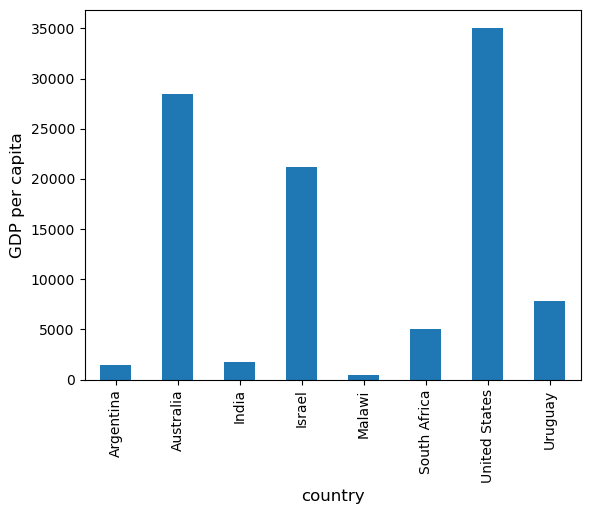

In [44]:
ax = df['GDP percap'].plot(kind='bar')
ax.set_xlabel('country', fontsize=12)
ax.set_ylabel('GDP per capita', fontsize=12)
plt.show()

ഇപ്പോൾ data frame countries-ന്റെ alphabetical order-ൽ ആണ്---GDP per capita-ന്റെ order-ലേക്ക് നമുക്ക് അത് മാറ്റാം

In [45]:
df = df.sort_values(by='GDP percap', ascending=False)
df

,population,total GDP,GDP percap
country,,,
United States,2.821720e+08,9.898700e+06,35080.381854
Australia,1.905319e+07,5.418047e+05,28436.433261
Israel,6.114570e+06,1.292539e+05,21138.672749
Uruguay,3.219793e+06,2.525596e+04,7843.970620
South Africa,4.506410e+07,2.272424e+05,5042.647686
India,1.006300e+09,1.728144e+06,1717.324719
Argentina,1.962465e+08,2.950722e+05,1503.579625
Malawi,1.180150e+07,5.026222e+03,425.896679


മുൻപത്തെപ്പോലെ plot ചെയ്യുമ്പോൾ ഇപ്പോൾ ഇത് ലഭിക്കുന്നു

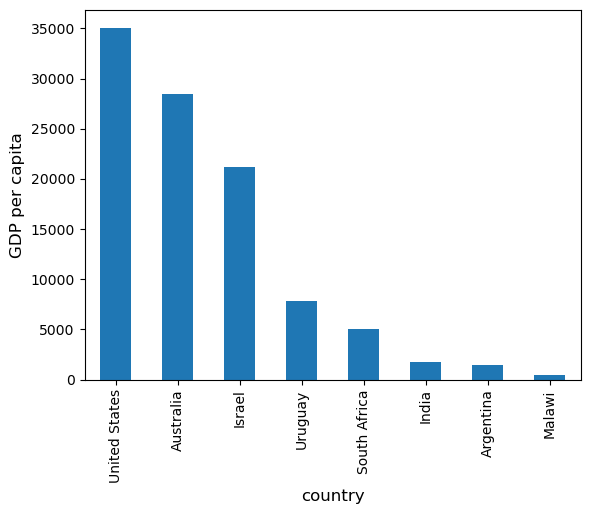

In [46]:
ax = df['GDP percap'].plot(kind='bar')
ax.set_xlabel('country', fontsize=12)
ax.set_ylabel('GDP per capita', fontsize=12)
plt.show()

## On-Line Data Sources

```{index} single: Data Sources
```

online databases-നെ programmatically query ചെയ്യുന്നത് Python straightforward ആക്കുന്നു.

economists-ന് ഒരു പ്രധാന database ആണ് [FRED](https://fred.stlouisfed.org/) --- St. Louis Fed maintain ചെയ്യുന്ന time series data-യുടെ ഒരു വലിയ collection.

ഉദാഹരണത്തിന്, [unemployment rate](https://fred.stlouisfed.org/series/UNRATE)-ൽ നമുക്ക് interest ഉണ്ട് എന്ന് കരുതുക.

(data csv ആയി download ചെയ്യാൻ, top right-ലെ `Download` click ചെയ്ത് `CSV (data)` option select ചെയ്യുക).

പകരമായി, ഒരു Python program-ൽ നിന്ന് നമുക്ക് CSV file access ചെയ്യാം.

ഇത് പല രീതികളിലും ചെയ്യാം.

താരതമ്യേന low-level ആയ ഒരു method-ൽ നമ്മൾ ആരംഭിച്ച് പിന്നീട് pandas-ലേക്ക് തിരിച്ചുവരും.

### Accessing Data with {index}`requests <single: requests>`

```{index} single: Python; requests
```

Internet-ൽ നിന്ന് data request ചെയ്യാനുള്ള standard Python library ആയ [requests](https://requests.readthedocs.io/en/latest/) ഉപയോഗിക്കുന്നതാണ് ഒരു option.

തുടങ്ങാൻ, നിങ്ങളുടെ computer-ൽ താഴെപ്പറയുന്ന code try ചെയ്യുക

In [47]:
r = requests.get('https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23e1e9f0&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1318&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=UNRATE&scale=left&cosd=1948-01-01&coed=2024-06-01&line_color=%234572a7&link_values=false&line_style=solid&mark_type=none&mw=3&lw=2&ost=-99999&oet=99999&mma=0&fml=a&fq=Monthly&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2024-07-29&revision_date=2024-07-29&nd=1948-01-01')

Error message ഒന്നും ഇല്ലെങ്കിൽ, call succeed ആയി എന്നാണ് അർത്ഥം.

Error ലഭിച്ചാൽ, സാധ്യതയുള്ള രണ്ട് കാരണങ്ങൾ ഉണ്ട്

1. നിങ്ങൾ Internet-ലേക്ക് connect ആയിട്ടില്ല --- ഇത് സംഭവിക്കില്ല എന്ന് പ്രതീക്ഷിക്കുന്നു.
1. നിങ്ങളുടെ machine ഒരു proxy server വഴിയാണ് Internet access ചെയ്യുന്നത്, Python-ന് ഇത് അറിയില്ല.

രണ്ടാമത്തെ case-ൽ, നിങ്ങൾക്ക് ഒന്നുകിൽ

* മറ്റൊരു machine-ലേക്ക് switch ചെയ്യാം
* [the documentation](https://requests.readthedocs.io/en/latest/) വായിച്ച് നിങ്ങളുടെ proxy problem പരിഹരിക്കാം

എല്ലാം work ചെയ്യുന്നു എന്ന് assume ചെയ്താൽ, `requests.get('https://research.stlouisfed.org/fred2/series/UNRATE/downloaddata/UNRATE.csv')` എന്ന call return ചെയ്ത `source` object നിങ്ങൾക്ക് ഇപ്പോൾ ഉപയോഗിക്കാം

In [48]:
url = 'https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23e1e9f0&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1318&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=UNRATE&scale=left&cosd=1948-01-01&coed=2024-06-01&line_color=%234572a7&link_values=false&line_style=solid&mark_type=none&mw=3&lw=2&ost=-99999&oet=99999&mma=0&fml=a&fq=Monthly&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2024-07-29&revision_date=2024-07-29&nd=1948-01-01'
source = requests.get(url).content.decode().split("\n")
source[0]

'observation_date,UNRATE'

In [49]:
source[1]

'1948-01-01,3.4'

In [50]:
source[2]

'1948-02-01,3.8'

ഈ text parse ചെയ്ത് ഒരു array ആയി store ചെയ്യാൻ നമുക്ക് ഇപ്പോൾ കുറച്ച് additional code എഴുതാം.

എന്നാൽ ഇത് unnecessary ആണ് --- pandas-ന്റെ `read_csv` function ഈ task നമുക്കായി handle ചെയ്യും.

pandas നമ്മുടെ dates column recognize ചെയ്യാൻ `parse_dates=True` നമ്മൾ ഉപയോഗിക്കുന്നു, ഇത് simple date filtering-ന് അനുവദിക്കുന്നു

In [51]:
data = pd.read_csv(url, index_col=0, parse_dates=True)

`data` എന്ന ഒരു pandas DataFrame-ലേക്ക് data read ചെയ്തിരിക്കുന്നു, ഇത് ഇപ്പോൾ പതിവ് രീതിയിൽ നമുക്ക് manipulate ചെയ്യാം

In [52]:
type(data)

pandas.DataFrame

In [53]:
data.head()  # A useful method to get a quick look at a data frame

,UNRATE
observation_date,
1948-01-01,3.4
1948-02-01,3.8
1948-03-01,4.0
1948-04-01,3.9
1948-05-01,3.5


In [54]:
pd.set_option('display.precision', 1)
data.describe()  # Your output might differ slightly

,UNRATE
count,918.0
mean,5.7
std,1.7
min,2.5
25%,4.4
50%,5.5
75%,6.7
max,14.8


2006 മുതൽ 2012 വരെയുള്ള unemployment rate ഇങ്ങനെയും നമുക്ക് plot ചെയ്യാം

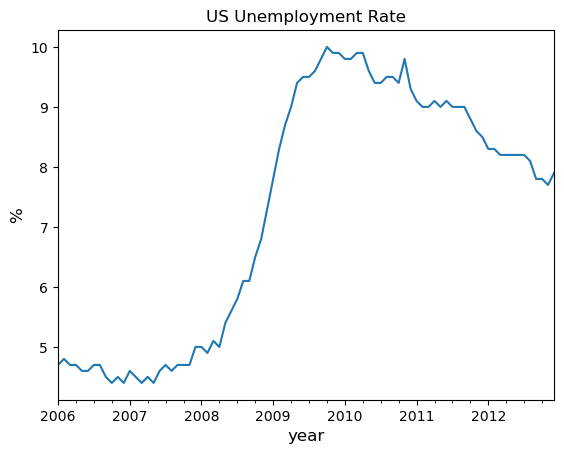

In [55]:
ax = data['2006':'2012'].plot(title='US Unemployment Rate', legend=False)
ax.set_xlabel('year', fontsize=12)
ax.set_ylabel('%', fontsize=12)
plt.show()

pandas മറ്റ് പല file type alternatives-ഉം offer ചെയ്യുന്നു എന്നത് ശ്രദ്ധിക്കുക.

Read, excel, json, parquet ചെയ്യാനോ ഒരു database server-ലേക്ക് നേരിട്ട് plug ചെയ്യാനോ നമുക്ക് ഉപയോഗിക്കാവുന്ന [a wide variety](https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html) top-level methods Pandas-ന് ഉണ്ട്.

### Using {index}`wbgapi <single: wbgapi>` and {index}`yfinance <single: yfinance>` to Access Data

World Bank publish ചെയ്യുന്ന പല databases-ൽ നിന്നും data fetch ചെയ്യാൻ [wbgapi](https://pypi.org/project/wbgapi/) python library ഉപയോഗിക്കാം.

```{note}
[wbgapi](https://pypi.org/project/wbgapi/) package-നെ കുറിച്ചുള്ള useful ആയ ചില information ഈ [world bank blog post](https://blogs.worldbank.org/en/opendata/introducing-wbgapi-new-python-package-accessing-world-bank-data)-ൽ, കൂടാതെ ഈ [tutorial](https://github.com/tgherzog/wbgapi/blob/master/examples/wbgapi-quickstart.ipynb)-ലും നിങ്ങൾക്ക് കണ്ടെത്താം
```

Exercises-ൽ Yahoo finance-ൽ നിന്ന് data fetch ചെയ്യാൻ [yfinance](https://pypi.org/project/yfinance/)-ഉം നമ്മൾ ഉപയോഗിക്കും.

ഇപ്പോൾ data download ചെയ്ത് plot ചെയ്യുന്നതിന്റെ ഒരു example നമുക്ക് നോക്കാം --- ഇത്തവണ World Bank-ൽ നിന്ന്.

World Bank ഒരു വലിയ range indicators-ൽ data [collect ചെയ്ത് organize ചെയ്യുന്നു](https://data.worldbank.org/indicator).

ഉദാഹരണത്തിന്, GDP-യുടെ ratio ആയി government debt-നെക്കുറിച്ചുള്ള ചില data [ഇതാ](https://data.worldbank.org/indicator/GC.DOD.TOTL.GD.ZS).

അടുത്ത code example നിങ്ങൾക്ക് വേണ്ടി data fetch ചെയ്ത് US-നും Australia-നും വേണ്ടിയുള്ള time series plot ചെയ്യുന്നു

In [56]:
import wbgapi as wb
wb.series.info('GC.DOD.TOTL.GD.ZS')

id,value
GC.DOD.TOTL.GD.ZS,"Central government debt, total (% of GDP)"
,1 elements


In [57]:
govt_debt = wb.data.DataFrame('GC.DOD.TOTL.GD.ZS', economy=['USA','AUS'], time=range(2005,2016))
govt_debt = govt_debt.T    # move years from columns to rows for plotting

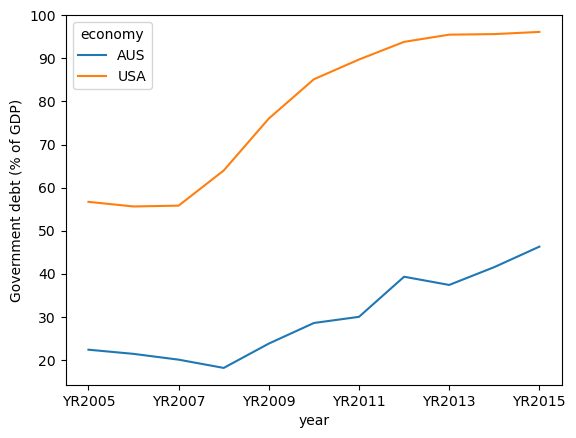

In [58]:
govt_debt.plot(xlabel='year', ylabel='Government debt (% of GDP)');

## Exercises

```{exercise-start}
:label: pd_ex1
```

ഈ imports ഉപയോഗിച്ച്:

In [59]:
import datetime as dt
import yfinance as yf

താഴെപ്പറയുന്ന shares-ന്റെ 2021-ലെ percentage price change calculate ചെയ്യാൻ ഒരു program എഴുതുക:

In [60]:
ticker_list = {'INTC': 'Intel',
               'MSFT': 'Microsoft',
               'IBM': 'IBM',
               'BHP': 'BHP',
               'TM': 'Toyota',
               'AAPL': 'Apple',
               'AMZN': 'Amazon',
               'C': 'Citigroup',
               'QCOM': 'Qualcomm',
               'KO': 'Coca-Cola',
               'GOOG': 'Google'}

program-ന്റെ ആദ്യ ഭാഗം ഇതാ

In [61]:
def read_data(ticker_list,
          start=dt.datetime(2021, 1, 1),
          end=dt.datetime(2021, 12, 31)):
    """
    This function reads in closing price data from Yahoo
    for each tick in the ticker_list.
    """
    ticker = pd.DataFrame()

    for tick in ticker_list:
        stock = yf.Ticker(tick)
        prices = stock.history(start=start, end=end)

        # Change the index to date-only
        prices.index = pd.to_datetime(prices.index.date)
        
        closing_prices = prices['Close']
        ticker[tick] = closing_prices

    return ticker

ticker = read_data(ticker_list)

Result-നെ ഇതുപോലുള്ള ഒരു bar graph ആയി plot ചെയ്യാൻ program complete ചെയ്യുക:

```{image} /_static/lecture_specific/pandas/pandas_share_prices.png
:scale: 80
:align: center
```

```{exercise-end}
```

```{solution-start} pd_ex1
:class: dropdown
```

percentage change calculate ചെയ്യാൻ Pandas ഉപയോഗിച്ച് ഈ problem approach ചെയ്യാൻ കുറച്ച് വഴികളുണ്ട്.

ആദ്യമായി, നിങ്ങൾക്ക് data extract ചെയ്ത് ഇതുപോലെ calculation perform ചെയ്യാം:

In [62]:
p1 = ticker.iloc[0]    #Get the first set of prices as a Series
p2 = ticker.iloc[-1]   #Get the last set of prices as a Series
price_change = (p2 - p1) / p1 * 100
price_change

INTC     6.9
MSFT    57.2
IBM     18.7
BHP     -2.2
TM      23.4
AAPL    38.6
AMZN     5.8
C        3.6
QCOM    25.3
KO      14.9
GOOG    69.0
dtype: float64

പകരമായി `periods` argument ഉപയോഗിച്ച് ശരിയായ calculation perform ചെയ്യാൻ configure ചെയ്ത ഒരു inbuilt method `pct_change` നിങ്ങൾക്ക് ഉപയോഗിക്കാം.

In [63]:
change = ticker.pct_change(periods=len(ticker)-1, axis='rows')*100
price_change = change.iloc[-1]
price_change

INTC     6.9
MSFT    57.2
IBM     18.7
BHP     -2.2
TM      23.4
AAPL    38.6
AMZN     5.8
C        3.6
QCOM    25.3
KO      14.9
GOOG    69.0
Name: 2021-12-30 00:00:00, dtype: float64

തുടർന്ന് chart plot ചെയ്യാൻ

In [64]:
price_change.sort_values(inplace=True)
price_change.rename(index=ticker_list, inplace=True)

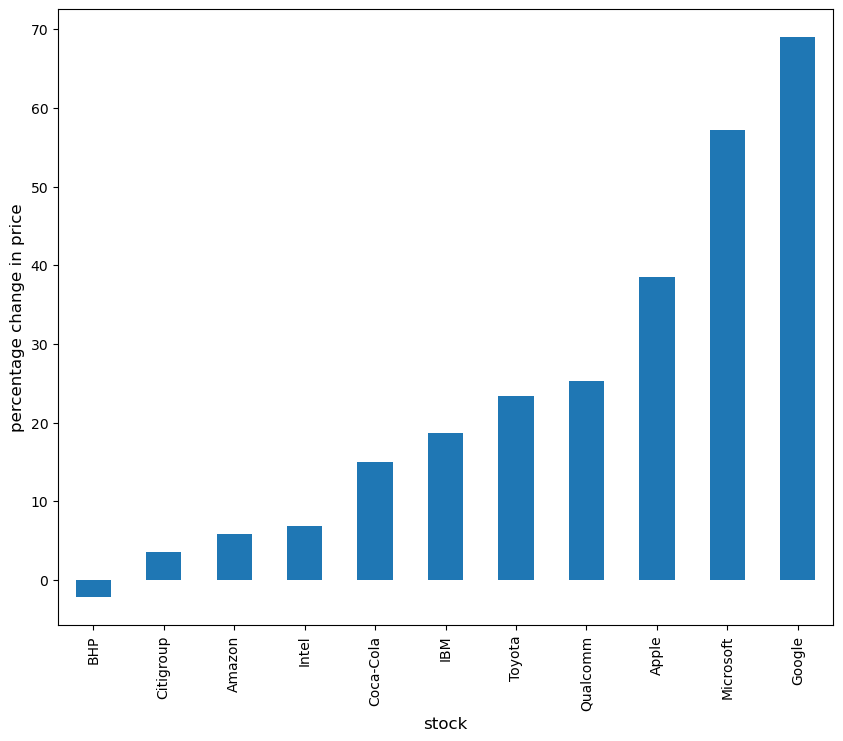

In [65]:
fig, ax = plt.subplots(figsize=(10,8))
ax.set_xlabel('stock', fontsize=12)
ax.set_ylabel('percentage change in price', fontsize=12)
price_change.plot(kind='bar', ax=ax)
plt.show()

```{solution-end}
```


```{exercise-start}
:label: pd_ex2
```

{ref}`pd_ex1`-ൽ introduce ചെയ്ത `read_data` method ഉപയോഗിച്ച്, താഴെപ്പറയുന്ന indices-ന്റെ year-on-year percentage change obtain ചെയ്യാൻ ഒരു program എഴുതുക:

In [66]:
indices_list = {'^GSPC': 'S&P 500',
               '^IXIC': 'NASDAQ',
               '^DJI': 'Dow Jones',
               '^N225': 'Nikkei'}

summary statistics കാണിക്കാനും result-നെ ഇതുപോലുള്ള ഒരു time series graph ആയി plot ചെയ്യാനും program complete ചെയ്യുക:

```{image} /_static/lecture_specific/pandas/pandas_indices_pctchange.png
:scale: 80
:align: center
```

```{exercise-end}
```

```{solution-start} pd_ex2
:class: dropdown
```

{ref}`pd_ex1`-ൽ നിങ്ങൾ ചെയ്ത work പിന്തുടർന്ന്, start, end dates അതനുസരിച്ച് update ചെയ്ത് `read_data` ഉപയോഗിച്ച് data നിങ്ങൾക്ക് query ചെയ്യാം.

In [67]:
indices_data = read_data(
        indices_list,
        start=dt.datetime(1971, 1, 1),  #Common Start Date
        end=dt.datetime(2021, 12, 31)
)

തുടർന്ന്, ഓരോ വർഷത്തിലെയും prices-ന്റെ ആദ്യത്തെയും അവസാനത്തെയും set DataFrames ആയി extract ചെയ്ത്, ഇതുപോലെ yearly returns calculate ചെയ്യുക:

In [68]:
yearly_returns = pd.DataFrame()

for index, name in indices_list.items():
    p1 = indices_data.groupby(indices_data.index.year)[index].first()  # Get the first set of returns as a DataFrame
    p2 = indices_data.groupby(indices_data.index.year)[index].last()   # Get the last set of returns as a DataFrame
    returns = (p2 - p1) / p1
    yearly_returns[name] = returns

yearly_returns

,S&P 500,NASDAQ,Dow Jones,Nikkei
1971,1.2e-01,1.4e-01,NaN,3.6e-01
1972,1.6e-01,1.8e-01,NaN,9.2e-01
1973,-1.8e-01,-3.2e-01,NaN,-1.8e-01
1974,-3.0e-01,-3.5e-01,NaN,-9.9e-02
1975,2.8e-01,2.8e-01,NaN,1.7e-01
1976,1.8e-01,2.5e-01,NaN,1.3e-01
1977,-1.1e-01,7.5e-02,NaN,-2.7e-02
1978,2.4e-02,1.3e-01,NaN,2.3e-01
1979,1.2e-01,2.8e-01,NaN,8.7e-02
1980,2.8e-01,3.7e-01,NaN,7.7e-02


അടുത്തതായി, `describe` method ഉപയോഗിച്ച് summary statistics നിങ്ങൾക്ക് obtain ചെയ്യാം.

In [69]:
yearly_returns.describe()

,S&P 500,NASDAQ,Dow Jones,Nikkei
count,5.1e+01,5.1e+01,3.0e+01,5.1e+01
mean,9.2e-02,1.3e-01,9.1e-02,7.9e-02
std,1.6e-01,2.5e-01,1.4e-01,2.4e-01
min,-3.8e-01,-4.0e-01,-3.3e-01,-4.0e-01
25%,-2.2e-03,1.6e-04,2.5e-02,-6.8e-02
50%,1.2e-01,1.4e-01,8.9e-02,7.7e-02
75%,2.0e-01,2.8e-01,2.1e-01,2.0e-01
max,3.4e-01,8.4e-01,3.3e-01,9.2e-01


തുടർന്ന്, chart plot ചെയ്യാൻ

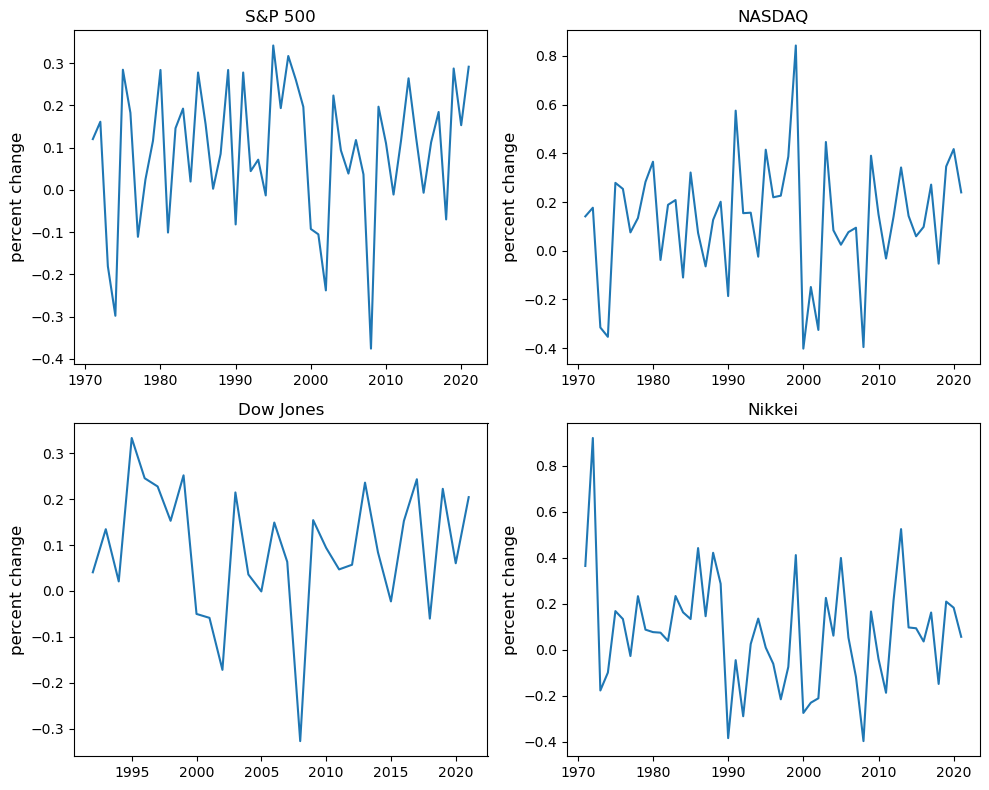

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for iter_, ax in enumerate(axes.flatten()):            # Flatten 2-D array to 1-D array
    index_name = yearly_returns.columns[iter_]         # Get index name per iteration
    ax.plot(yearly_returns[index_name])                # Plot pct change of yearly returns per index
    ax.set_ylabel("percent change", fontsize = 12)
    ax.set_title(index_name)

plt.tight_layout()

```{solution-end}
```

[^mung]: raw data-യിൽ നിന്ന് structured ആയ, purged ആയ ഒരു form-ലേക്ക് data clean ചെയ്യുന്നതിനെ munging എന്ന് Wikipedia define ചെയ്യുന്നു.